Which policies are likely to renew, lapse, or cancel — and what factors are associated with non-renewal?

Renewal Status
      ↓
Renewal Rate
      ↓
Premium Increase
      ↓
Claim History
      ↓
Loyalty
      ↓
Contact Channel
      ↓
Payment / Claim Behavior
      ↓
Create ML Target
      ↓
Policy-Level Renewal Features

Motor Policy
Start: 01-Jan-2025
End:   31-Dec-2025

insurer asks:

Would you like to continue coverage for another year?

The customer may:

Renew
Lapse
Cancel
Pending decision

Renewed

Customer continues the policy.

Lapsed

Policy wasn't continued, often because renewal/premium requirements were not completed.

Cancelled

Policy was intentionally terminated.

Pending

Final renewal outcome isn't known yet.

This distinction becomes extremely important for ML.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

In [2]:
renewals_df = pd.read_csv(
    DATA_DIR / "renewals.csv"
)

policies_df = pd.read_csv(
    DATA_DIR / "policies.csv"
)

customers_df = pd.read_csv(
    DATA_DIR / "customers.csv"
)

print("Renewals :", renewals_df.shape)
print("Policies :", policies_df.shape)
print("Customers:", customers_df.shape)

Renewals : (20000, 12)
Policies : (150000, 15)
Customers: (100000, 12)


In [3]:
renewals_df.columns.tolist()

['RENEWAL_ID',
 'POLICY_ID',
 'CUSTOMER_ID',
 'RENEWAL_DUE_DATE',
 'OLD_PREMIUM',
 'NEW_PREMIUM',
 'PREMIUM_INCREASE_PCT',
 'CLAIM_HISTORY_FLAG',
 'LOYALTY_YEARS',
 'RENEWAL_PROBABILITY',
 'RENEWAL_STATUS',
 'CONTACT_CHANNEL']

Grain
1 row = 1 renewal record

In [4]:
renewals_df["POLICY_ID"].duplicated().sum()

np.int64(0)

In [5]:
renewals_df["RENEWAL_DUE_DATE"] = pd.to_datetime(renewals_df["RENEWAL_DUE_DATE"],errors="coerce")

In [6]:
# Renewal Status Distribution
renewal_status = (renewals_df["RENEWAL_STATUS"].value_counts())

renewal_status

RENEWAL_STATUS
Renewed      17334
Lapsed        1463
Pending        796
Cancelled      407
Name: count, dtype: int64

In [7]:
renewal_status_pct = (
    renewals_df["RENEWAL_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

renewal_status_pct

RENEWAL_STATUS
Renewed      86.67
Lapsed        7.32
Pending       3.98
Cancelled     2.04
Name: proportion, dtype: float64

Among all 20,000 renewal records:

86.67% Renewed

which looks strong.

But be careful.

Pending means we don't know the final result yet.

For ML, this creates a very important distinction.

Descriptive Rate vs ML Target

For dashboard reporting we can show all:

Renewed
Lapsed
Cancelled
Pending

But for our first binary ML model:

Renewed   → 1

Lapsed    → 0
Cancelled → 0

Pending   → EXCLUDE

Create finalized renewal dataset

In [8]:
finalized_renewals = renewals_df[renewals_df["RENEWAL_STATUS"] != "Pending"].copy()

In [9]:
finalized_renewals.shape

(19204, 12)

Now create target:

In [10]:
finalized_renewals["RENEWED_FLAG"] = (finalized_renewals["RENEWAL_STATUS"] == "Renewed").astype(int)

In [11]:
finalized_renewals["RENEWED_FLAG"].value_counts()

RENEWED_FLAG
1    17334
0     1870
Name: count, dtype: int64

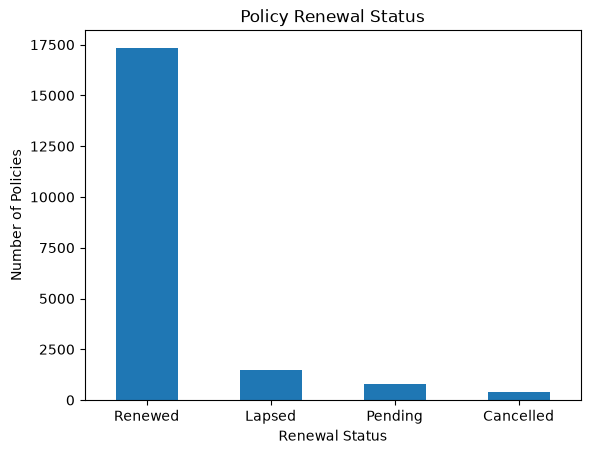

In [12]:
renewal_status.plot(
    kind="bar"
)

plt.title("Policy Renewal Status")
plt.xlabel("Renewal Status")
plt.ylabel("Number of Policies")
plt.xticks(rotation=0)

plt.show()

Premium Increase — Major Business Variable

we have old premium, new premium , premimum pct 

                       New Premium - Old Premium
Premium Increase % = ----------------------------- × 100
                            Old Premium

In [ ]:
renewals_df[[ "OLD_PREMIUM", "NEW_PREMIUM", "PREMIUM_INCREASE_PCT" ]].describe() 

,OLD_PREMIUM,NEW_PREMIUM,PREMIUM_INCREASE_PCT
count,20000.000000,20000.000000,20000.000000
mean,19331.410950,20699.031200,7.041559
std,14301.803015,15378.435784,4.954275
min,1200.000000,1217.000000,-11.200000
25%,10456.250000,11146.250000,3.680000
50%,15608.500000,16718.500000,7.070000
75%,23354.000000,25069.250000,10.410000
max,145470.000000,161195.000000,33.360000


Create Premium Increase Bands

In [14]:
renewals_df["PREMIUM_INCREASE_BAND"] = pd.cut(
    renewals_df["PREMIUM_INCREASE_PCT"],
    bins=[-999, 5, 10, 15, 999],
    labels=["Below 5%", "5-10%", "10-15%", "15%+"],
    right=False
)

In [15]:
renewals_df[
    "PREMIUM_INCREASE_BAND"
].value_counts().sort_index()

PREMIUM_INCREASE_BAND
Below 5%    6850
5-10%       7591
10-15%      4508
15%+        1051
Name: count, dtype: int64

Renewal Rate by Premium Increase

In [16]:
premium_renewal = renewals_df.groupby(
    "PREMIUM_INCREASE_BAND",
    observed=False
).agg(
    TOTAL_RENEWALS=("RENEWAL_ID", "count"),
    RENEWED=("RENEWAL_STATUS", lambda x: (x == "Renewed").sum())
).reset_index()

In [17]:
premium_renewal["RENEWAL_RATE"] = premium_renewal["RENEWED"] / premium_renewal["TOTAL_RENEWALS"] * 100

premium_renewal

,PREMIUM_INCREASE_BAND,TOTAL_RENEWALS,RENEWED,RENEWAL_RATE
0,Below 5%,6850,6103,89.094891
1,5-10%,7591,6717,88.486365
2,10-15%,4508,3730,82.741792
3,15%+,1051,784,74.595623


Better ML Version — Exclude Pending

In [18]:
finalized_renewals["PREMIUM_INCREASE_BAND"] = pd.cut(
    finalized_renewals["PREMIUM_INCREASE_PCT"],
    bins=[-999, 5, 10, 15, 999],
    labels=["Below 5%", "5-10%", "10-15%", "15%+"],
    right=False
)

In [19]:
premium_renewal_rate = finalized_renewals.groupby(
    "PREMIUM_INCREASE_BAND",
    observed=False
)["RENEWED_FLAG"].mean() * 100

premium_renewal_rate.round(2)

PREMIUM_INCREASE_BAND
Below 5%    92.27
5-10%       91.57
10-15%      87.31
15%+        79.76
Name: RENEWED_FLAG, dtype: float64

Why higher than before?

Because Pending cases were removed.

That's why you always need to define the denominator clearly.

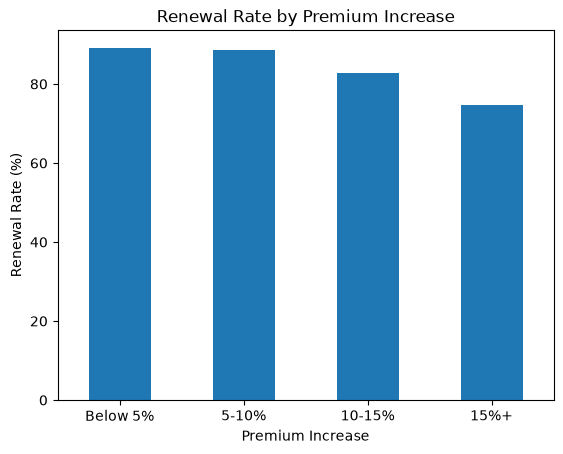

In [20]:
premium_renewal.plot(
    x="PREMIUM_INCREASE_BAND",
    y="RENEWAL_RATE",
    kind="bar",
    legend=False
)

plt.title(
    "Renewal Rate by Premium Increase"
)

plt.xlabel(
    "Premium Increase"
)

plt.ylabel(
    "Renewal Rate (%)"
)

plt.xticks(rotation=0)

plt.show()

In [ ]:
# Claim History vs Renewal

In [21]:
claim_renewal = pd.crosstab(
    renewals_df["CLAIM_HISTORY_FLAG"],
    renewals_df["RENEWAL_STATUS"],
    normalize="index"
) * 100

claim_renewal.round(2)

RENEWAL_STATUS,Cancelled,Lapsed,Pending,Renewed
CLAIM_HISTORY_FLAG,,,,
No,1.83,6.19,3.18,88.80
Yes,2.61,10.52,6.24,80.62


Customers with claim history have lower renewal rates.

Finalized Renewal Rate by Claim History

In [22]:
(
    finalized_renewals
    .groupby("CLAIM_HISTORY_FLAG")
    ["RENEWED_FLAG"]
    .mean()
    .mul(100)
    .round(2)
)

CLAIM_HISTORY_FLAG
No     91.72
Yes    85.99
Name: RENEWED_FLAG, dtype: float64

Validate CLAIM_HISTORY_FLAG against actual Claims

Does CLAIM_HISTORY_FLAG = Yes actually agree with the claims table?

In [23]:
claims_df = pd.read_csv(
    DATA_DIR / "claims.csv"
)

In [25]:
claim_policy_ids = set(
    claims_df["POLICY_ID"].unique()
)

In [26]:
renewals_df["ACTUAL_CLAIM_HISTORY"] = renewals_df["POLICY_ID"].isin(claim_policy_ids)

In [27]:
pd.crosstab(
    renewals_df["CLAIM_HISTORY_FLAG"],
    renewals_df["ACTUAL_CLAIM_HISTORY"]
)

ACTUAL_CLAIM_HISTORY,False,True
CLAIM_HISTORY_FLAG,,
No,8854,5939
Yes,3224,1983


Senior Analyst Decision

For descriptive analysis:

CLAIM_HISTORY_FLAG

can be reported as the source renewal-system field.

But for our engineered ML dataset, I'd prefer the actual aggregated claim features we created in:

policy_claim_features.csv

because they are traceable directly to the claims dataset.

This is exactly why cross-table validation matters.

In [28]:
renewals_df[
    "LOYALTY_YEARS"
].describe()

count    20000.000000
mean         4.514300
std          2.278389
min          1.000000
25%          3.000000
50%          5.000000
75%          6.000000
max          8.000000
Name: LOYALTY_YEARS, dtype: float64

In [29]:
loyalty_renewal = finalized_renewals.groupby("LOYALTY_YEARS").agg(
    POLICIES=("POLICY_ID", "count"),
    RENEWAL_RATE=("RENEWED_FLAG", "mean")
).reset_index()

In [30]:
loyalty_renewal[
    "RENEWAL_RATE"
] *= 100

loyalty_renewal.round(2)

,LOYALTY_YEARS,POLICIES,RENEWAL_RATE
0,1,2324,88.60
1,2,2354,88.57
2,3,2376,89.52
3,4,2456,89.29
4,5,2432,91.08
5,6,2454,91.24
6,7,2429,91.97
7,8,2379,91.72


Interpretation

Longer-tenure customers show somewhat higher renewal rates.

Conceptually:

Loyalty ↑
    ↓
Renewal tendency ↑

In [31]:
channel_renewal = finalized_renewals.groupby("CONTACT_CHANNEL").agg(
    POLICIES=("POLICY_ID", "count"),
    RENEWAL_RATE=("RENEWED_FLAG", "mean")
).reset_index()

In [32]:
channel_renewal["RENEWAL_RATE"] = channel_renewal["RENEWAL_RATE"] * 100

channel_renewal = channel_renewal.sort_values(
    "RENEWAL_RATE",
    ascending=False
).round(2)

channel_renewal

,CONTACT_CHANNEL,POLICIES,RENEWAL_RATE
1,Call,3835,91.08
2,Email,3904,90.57
4,WhatsApp,3823,90.43
3,SMS,3870,89.90
0,Agent Visit,3772,89.32


Interpretation

Differences are relatively small.

Don't conclude:

“Calling customers is definitely the best retention strategy.”

Very Important Column — RENEWAL_PROBABILITY

In [33]:
renewals_df.groupby(
    "RENEWAL_STATUS"
)["RENEWAL_PROBABILITY"].mean()

RENEWAL_STATUS
Cancelled    0.853091
Lapsed       0.848188
Pending      0.849425
Renewed      0.875828
Name: RENEWAL_PROBABILITY, dtype: float64

In [34]:
renewal_policy_df = finalized_renewals.merge(
    policies_df[
        ["POLICY_ID", "POLICY_TYPE", "ANNUAL_PREMIUM",
         "SUM_INSURED", "RISK_SCORE", "RISK_BAND", "SALES_CHANNEL"]
    ],
    on="POLICY_ID",
    how="left",
    validate="one_to_one"
)

In [35]:
product_renewal = renewal_policy_df.groupby("POLICY_TYPE").agg(
    POLICIES=("POLICY_ID", "count"),
    RENEWAL_RATE=("RENEWED_FLAG", "mean")
).reset_index()

In [37]:
product_renewal[
    "RENEWAL_RATE"
] *= 100

In [38]:
product_renewal.sort_values(
    "RENEWAL_RATE",
    ascending=False
).round(2)

,POLICY_TYPE,POLICIES,RENEWAL_RATE
6,Travel,1151,92.09
5,Term Life,3046,90.74
7,Whole Life,1292,90.71
0,Commercial,2033,90.46
1,Health,4571,89.98
4,Personal Accident,1536,89.91
3,Motor,3990,89.85
2,Home,1585,89.59


In [39]:
renewal_customer_df = (
    renewal_policy_df
    .merge(
        customers_df[
            [
                "CUSTOMER_ID",
                "AGE",
                "GENDER",
                "OCCUPATION",
                "ANNUAL_INCOME",
                "CREDIT_SCORE",
                "CUSTOMER_RISK_SEGMENT"
            ]
        ],
        on="CUSTOMER_ID",
        how="left",
        validate="many_to_one"
    )
)

In [42]:
risk_renewal = (
    renewal_customer_df
    .groupby(
        "CUSTOMER_RISK_SEGMENT"
    )
    .agg(
        POLICIES=(
            "POLICY_ID",
            "count"
        ),

        RENEWAL_RATE=(
            "RENEWED_FLAG",
            "mean"
        )
    )
    .reset_index()
)

In [44]:
risk_renewal[
    "RENEWAL_RATE"
] *= 100

risk_renewal.round(2)

,CUSTOMER_RISK_SEGMENT,POLICIES,RENEWAL_RATE
0,High,2108,90.61
1,Low,10590,90.29
2,Medium,6506,90.10


Customer risk segment doesn't show a strong direct renewal relationship in this synthetic data.

Bring in Our Payment Features

In [45]:
payment_features = pd.read_csv(
    PROCESSED_DIR /
    "policy_payment_features.csv"
)

In [47]:
renewal_analysis_df = (
    renewal_customer_df
    .merge(
        payment_features,
        on=[
            "POLICY_ID",
            "CUSTOMER_ID"
        ],
        how="left",
        validate="one_to_one"
    )
)

In [48]:
claim_features = pd.read_csv(
    PROCESSED_DIR /
    "policy_claim_features.csv"
)

In [49]:
renewal_analysis_df = (
    renewal_analysis_df
    .merge(
        claim_features,
        on=[
            "POLICY_ID",
            "CUSTOMER_ID"
        ],
        how="left",
        validate="one_to_one"
    )
)

Payment Delay vs Renewal

In [50]:
payment_renewal_df = renewal_analysis_df[
    renewal_analysis_df["AVG_PAYMENT_DELAY"].notna()
].copy()

In [51]:
payment_renewal_df["AVG_DELAY_BAND"] = pd.cut(
    payment_renewal_df["AVG_PAYMENT_DELAY"],
    bins=[-float("inf"), 0, 7, 15, 30, float("inf")],
    labels=["On Time", "1-7 Days", "8-15 Days", "16-30 Days", "30+ Days"]
)

In [52]:
(
    payment_renewal_df
    .groupby(
        "AVG_DELAY_BAND",
        observed=False
    )["RENEWED_FLAG"]
    .mean()
    .mul(100)
    .round(2)
)

AVG_DELAY_BAND
On Time       90.62
1-7 Days      90.06
8-15 Days     89.91
16-30 Days    88.23
30+ Days      89.41
Name: RENEWED_FLAG, dtype: float64

What Are Our Strongest Renewal Signals So Far?

From EDA:

Stronger visible relationship
PREMIUM_INCREASE_PCT

Higher increase → lower renewal.

Moderate relationship
LOYALTY_YEARS

Longer loyalty → somewhat higher renewal.

Mild potential relationship
AVG_PAYMENT_DELAY

Longer delay → somewhat lower renewal.

Weak/no obvious relationship
CUSTOMER_RISK_SEGMENT
CONTACT_CHANNEL
actual claim presence

And:

RENEWAL_PROBABILITY

should not be used as an independent model feature.

Excellent.

This is precisely why we do EDA before ML.

Build the Renewal Feature Base

In [53]:
renewal_features = (
    finalized_renewals[
        [
            "POLICY_ID",
            "CUSTOMER_ID",
            "OLD_PREMIUM",
            "NEW_PREMIUM",
            "PREMIUM_INCREASE_PCT",
            "CLAIM_HISTORY_FLAG",
            "LOYALTY_YEARS",
            "CONTACT_CHANNEL",
            "RENEWAL_STATUS",
            "RENEWED_FLAG"
        ]
    ]
    .copy()
)

intentionally excluded:

RENEWAL_PROBABILITY

because we don't want leakage in our independent model.

Create Useful Additional Feature

In [54]:
renewal_features["PREMIUM_CHANGE_AMOUNT"] = renewal_features["NEW_PREMIUM"] - renewal_features["OLD_PREMIUM"]

In [55]:
renewal_features["PREMIUM_INCREASED_FLAG"] = (
    renewal_features["NEW_PREMIUM"] > renewal_features["OLD_PREMIUM"]
).astype(int)

In [56]:
renewal_features.head()

,POLICY_ID,CUSTOMER_ID,OLD_PREMIUM,NEW_PREMIUM,PREMIUM_INCREASE_PCT,CLAIM_HISTORY_FLAG,LOYALTY_YEARS,CONTACT_CHANNEL,RENEWAL_STATUS,RENEWED_FLAG,PREMIUM_CHANGE_AMOUNT,PREMIUM_INCREASED_FLAG
0,POL000051250,CUST00059258,11390,12441,9.23,Yes,7,WhatsApp,Renewed,1,1051,1
1,POL000017253,CUST00094235,13513,13983,3.48,No,5,SMS,Renewed,1,470,1
2,POL000108220,CUST00031120,20696,20942,1.19,No,2,SMS,Renewed,1,246,1
3,POL000068626,CUST00061811,11112,11584,4.25,No,7,Call,Renewed,1,472,1
4,POL000134055,CUST00024866,13833,15043,8.75,Yes,4,SMS,Renewed,1,1210,1


In [57]:
renewal_features[
    "RENEWED_FLAG"
].isna().sum()

np.int64(0)

In [58]:
renewal_features[
    "RENEWED_FLAG"
].value_counts()

RENEWED_FLAG
1    17334
0     1870
Name: count, dtype: int64

We expect strong class imbalance toward:

1 = Renewed

That's something we'll deal with later during model evaluation.

In [59]:
renewal_features.to_csv(
    PROCESSED_DIR /
    "policy_renewal_features.csv",
    index=False
)

20,000 Renewal Records
        ↓
86.67% Renewed
        ↓
Pending outcomes removed
for ML target
        ↓
19,204 finalized outcomes
        ↓
Large premium increases
show lower renewal
        ↓
15%+ increase
has materially lower retention
        ↓
Higher loyalty shows
somewhat better renewal
        ↓
Payment delays may show
mild retention deterioration
        ↓
Customer risk/channel
show little separation
        ↓
Renewal Probability identified
as potential leakage
        ↓
Clean binary target created

What appears to be the most actionable retention signal?”